In [ ]:
df = pd.read_csv("exchange_rate.csv")
df.columns = ['Date', 'USD_AUD']  # Rename for consistency

# Correct date format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

df.set_index('Date', inplace=True)
df.head()


,USD_AUD
Date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [ ]:
!pip install --upgrade numpy


  Using cached numpy-2.3.2-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
Using cached numpy-2.3.2-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.0
    Uninstalling numpy-1.23.0:
      Successfully uninstalled numpy-1.23.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.2 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.2 which is incompatible.
cupy-cuda12x 13.3.0 requires numpy<2.3,>=1.22, but you have numpy 2.3.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.3.2 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and format the dataset
df = pd.read_csv("exchange_rate.csv")
df.columns = ['Date', 'USD_AUD']
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)

# Differencing to remove trend
diff_series = df['USD_AUD'].diff().dropna()


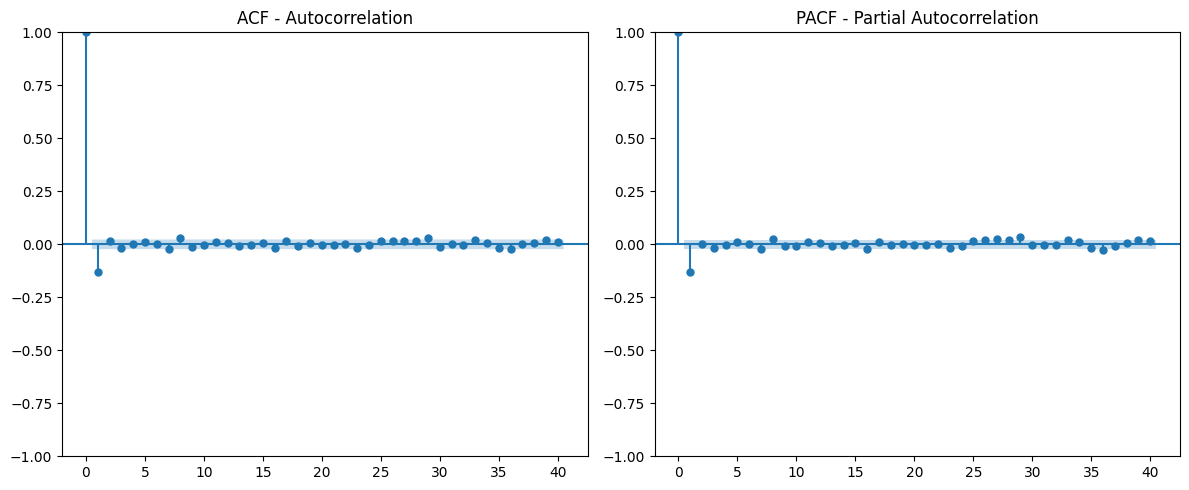

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_acf(diff_series, lags=40, ax=plt.gca())
plt.title("ACF - Autocorrelation")

plt.subplot(1, 2, 2)
plot_pacf(diff_series, lags=40, ax=plt.gca(), method='ywm')
plt.title("PACF - Partial Autocorrelation")

plt.tight_layout()
plt.show()


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model: (p=1, d=1, q=1) – you can tune these later based on AIC
model = ARIMA(df['USD_AUD'], order=(1, 1, 1))
model_fit = model.fit()

# Summary of the model
print(model_fit.summary())


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                USD_AUD   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Fri, 25 Jul 2025   AIC                         -56102.322
Time:                        12:30:03   BIC                         -56081.519
Sample:                    01-01-1990   HQIC                        -56095.182
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

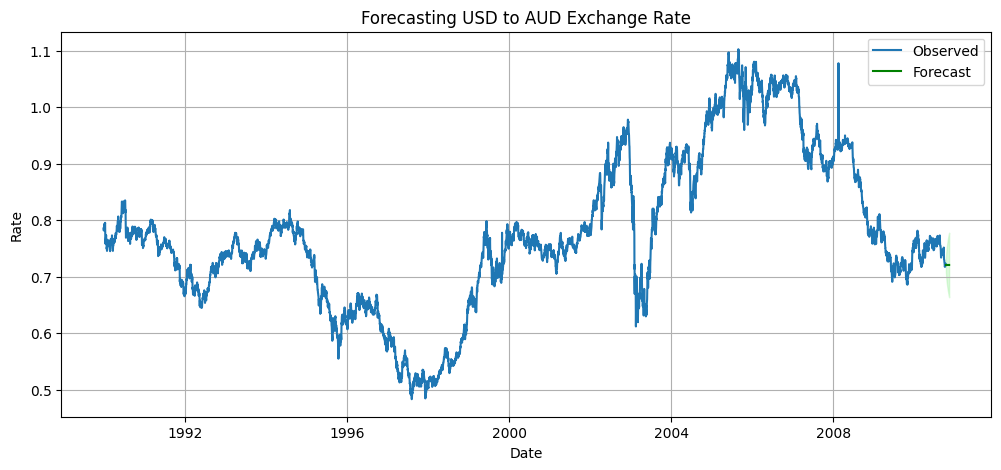

In [ ]:
# Forecast the next 30 steps
forecast = model_fit.get_forecast(steps=30)
forecast_df = forecast.summary_frame()

# Plot original data + forecast
plt.figure(figsize=(12, 5))
plt.plot(df['USD_AUD'], label='Observed')
plt.plot(forecast_df['mean'], label='Forecast', color='green')
plt.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], color='lightgreen', alpha=0.3)
plt.title("Forecasting USD to AUD Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.legend()
plt.grid(True)
plt.show()


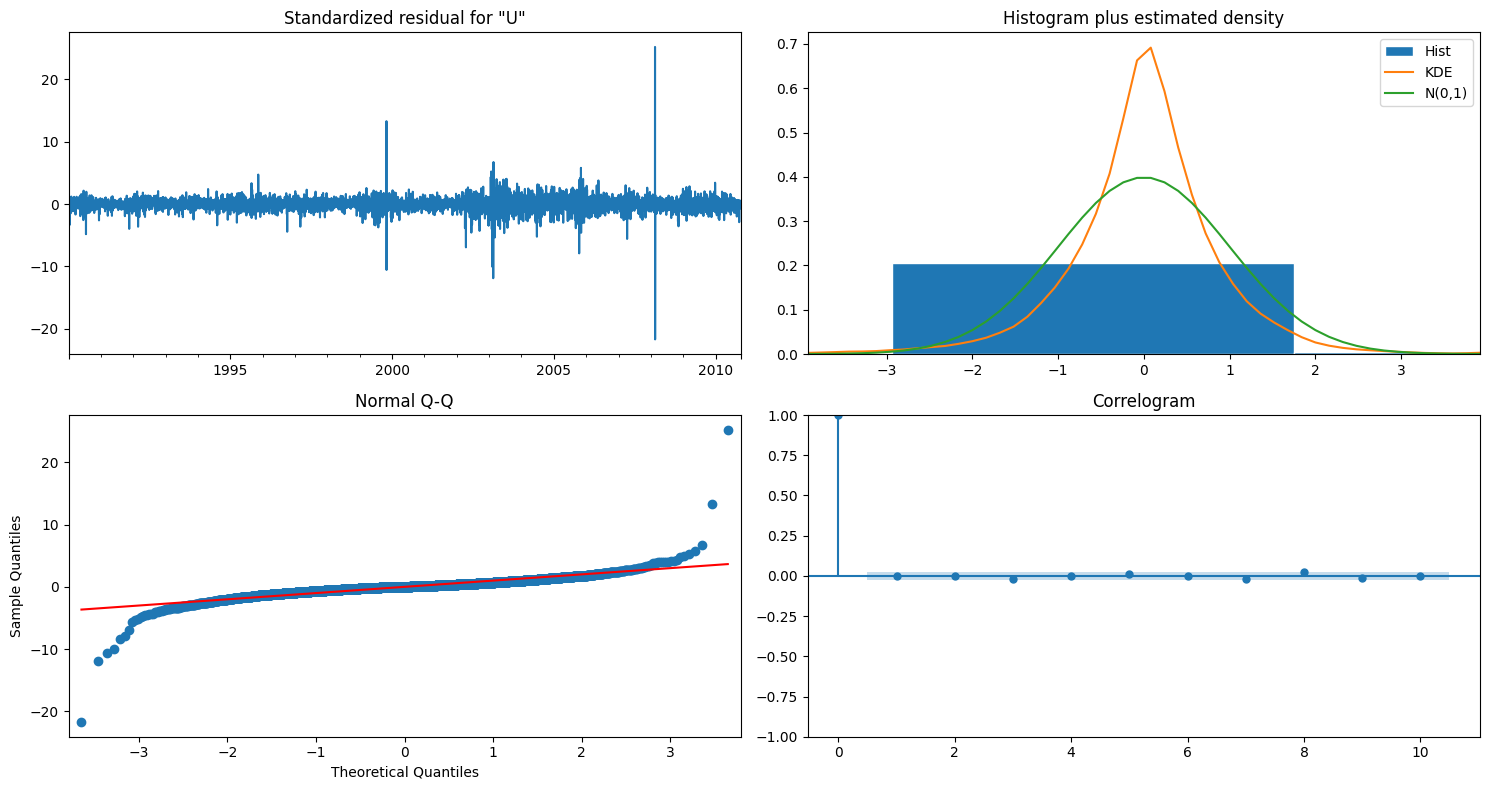

In [ ]:
model_fit.plot_diagnostics(figsize=(15, 8))
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Let's use the last 30 days as a test set
train = df.iloc[:-30]
test = df.iloc[-30:]

# Fit on training set
model = ARIMA(train['USD_AUD'], order=(1, 1, 1))
model_fit = model.fit()

# Forecast for test period
forecast = model_fit.forecast(steps=30)

# Compare
mae = mean_absolute_error(test['USD_AUD'], forecast)
rmse = np.sqrt(mean_squared_error(test['USD_AUD'], forecast))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


MAE: 0.0135
RMSE: 0.0166


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


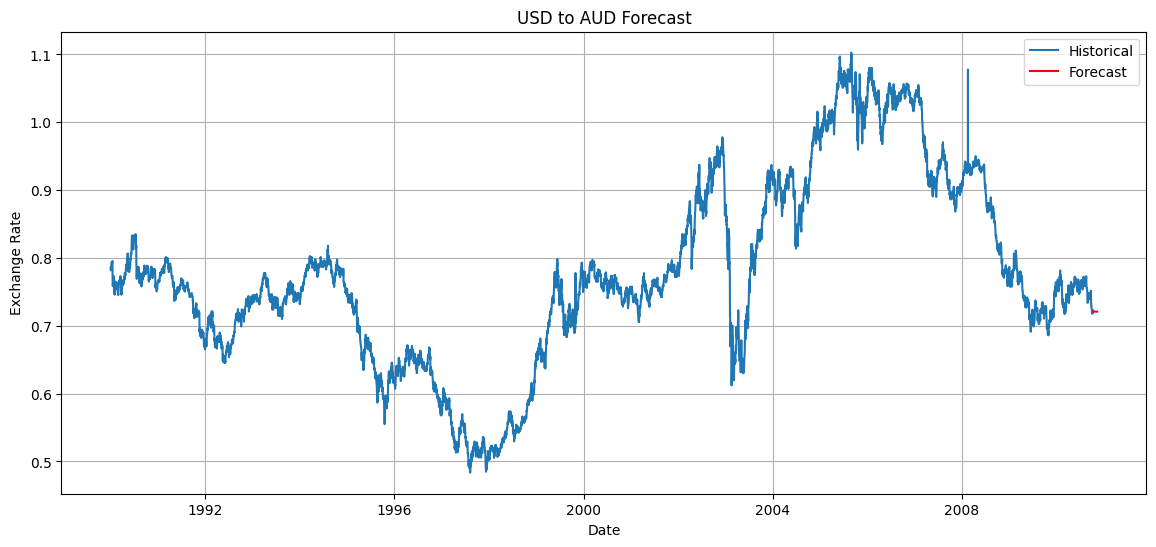

In [ ]:
# Retrain on full data
final_model = ARIMA(df['USD_AUD'], order=(1, 1, 1))  # use the best order you found
final_model_fit = final_model.fit()

# Forecast next 30 days
forecast_steps = 30
forecast = final_model_fit.forecast(steps=forecast_steps)

# Create future dates
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps)

# Create forecast DataFrame
forecast_df = pd.DataFrame({'Date': future_dates, 'Forecasted_USD_AUD': forecast})
forecast_df.set_index('Date', inplace=True)

# Plot
plt.figure(figsize=(14,6))
plt.plot(df['USD_AUD'], label='Historical')
plt.plot(forecast_df, label='Forecast', color='red')
plt.title("USD to AUD Forecast")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
forecast_df.to_csv("forecast_usd_aud.csv")


NEW CODE


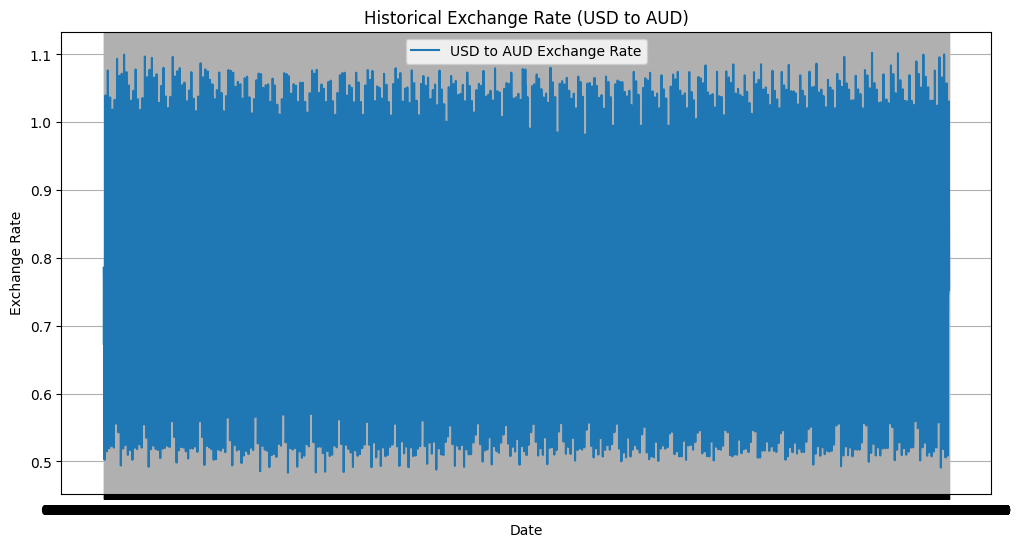

Missing values: 0


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("exchange_rate.csv", parse_dates=['date'], index_col='date')
df = df.sort_index()

# Rename column for clarity
df.rename(columns={'Ex_rate': 'Exchange_Rate'}, inplace=True)
series = df['Exchange_Rate']

# Initial exploration
plt.figure(figsize=(12, 6))
plt.plot(series, label='USD to AUD Exchange Rate')
plt.title("Historical Exchange Rate (USD to AUD)")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(True)
plt.show()

# Check and handle missing values
print("Missing values:", series.isnull().sum())
series = series.interpolate(method='linear')